In [40]:
# ==============================
# 1. Load data
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/minhmom2557/air-quality/hanoi_air_quality (1).csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.head())
print(df.info())
print(df.describe())

            timestamp  temperature  humidity  wind_speed  pressure  hour  \
0 2025-11-13 00:00:00         20.8        81    1.361111    1015.2     0   
1 2025-11-13 01:00:00         20.1        81    2.166667    1015.3     1   
2 2025-11-13 02:00:00         20.1        76    2.583333    1015.0     2   
3 2025-11-13 03:00:00         20.4        72    2.500000    1015.1     3   
4 2025-11-13 04:00:00         20.5        70    2.361111    1015.9     4   

   day_of_week  is_weekend  wind_direction  precipitation  cloud_cover  \
0            3           0             356            0.0          100   
1            3           0               8            0.0          100   
2            3           0               9            0.0           91   
3            3           0              13            0.0           98   
4            3           0              18            0.0           99   

   is_warning  aqi  pm25  
0           1  113  80.6  
1           1  114  58.3  
2           1  11

In [41]:
# ==============================
# 2. Privacy & method write-up
# ==============================
start_date = df["timestamp"].min()
end_date = df["timestamp"].max()
duration = end_date - start_date

print("Privacy & Method Summary")
print("------------------------")
print("This dataset does not contain personal data.")
print("It only includes environmental and weather-related variables such as AQI, PM2.5, temperature, humidity, wind speed, and time.")
print("The data source/API terms of service should be documented in the report.")
print(f"Collection period: from {start_date} to {end_date}")
print(f"Collection duration: {duration}")
print(f"Number of records: {len(df)}")
print(f"Number of features: {df.shape[1]}")

Privacy & Method Summary
------------------------
This dataset does not contain personal data.
It only includes environmental and weather-related variables such as AQI, PM2.5, temperature, humidity, wind speed, and time.
The data source/API terms of service should be documented in the report.
Collection period: from 2025-11-13 00:00:00 to 2026-05-12 23:00:00
Collection duration: 180 days 23:00:00
Number of records: 4344
Number of features: 14


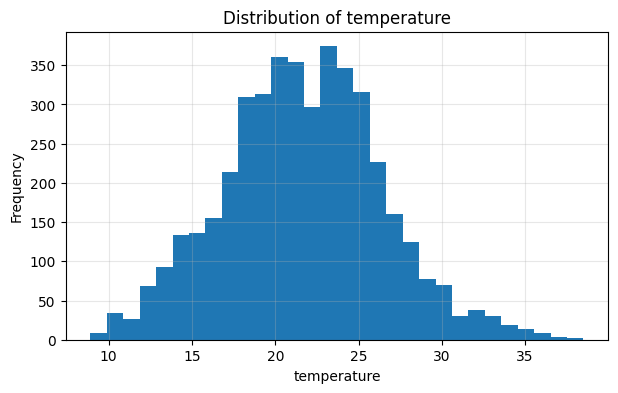

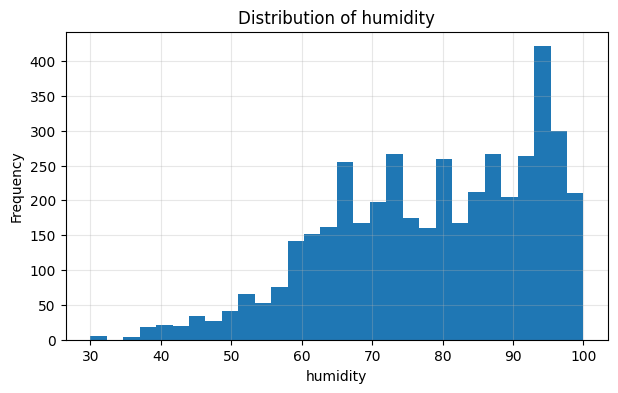

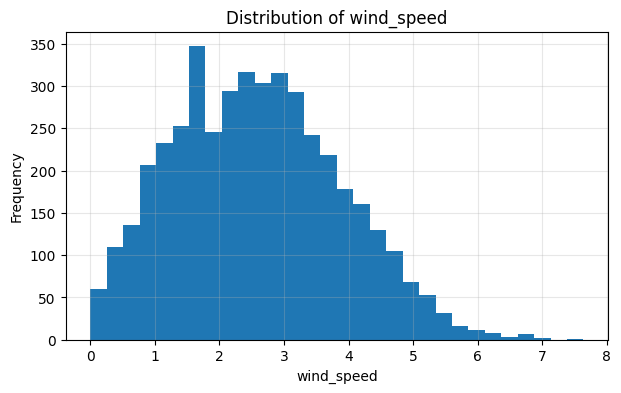

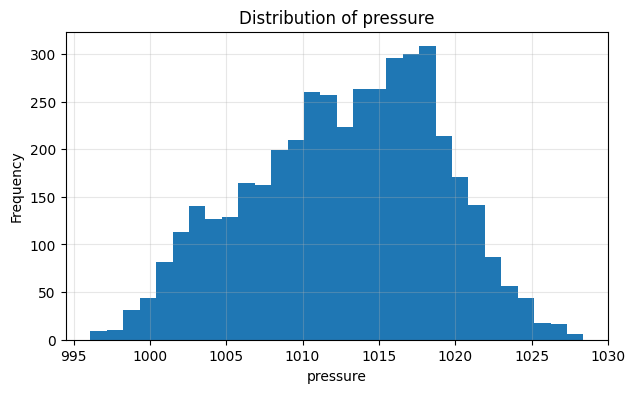

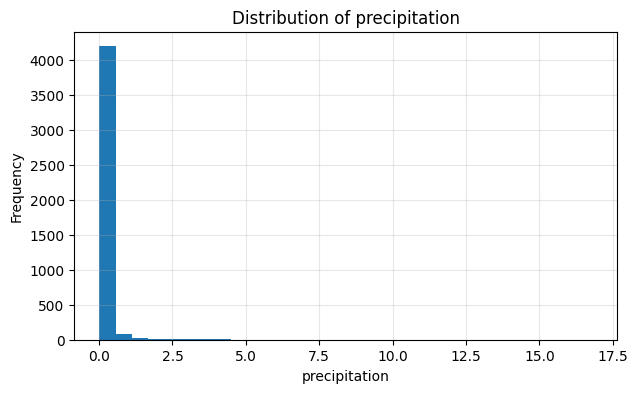

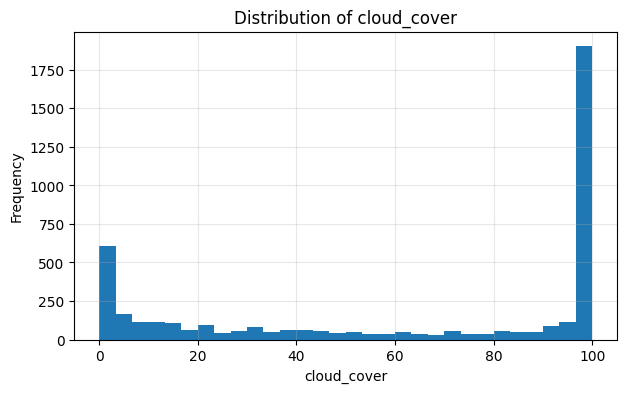

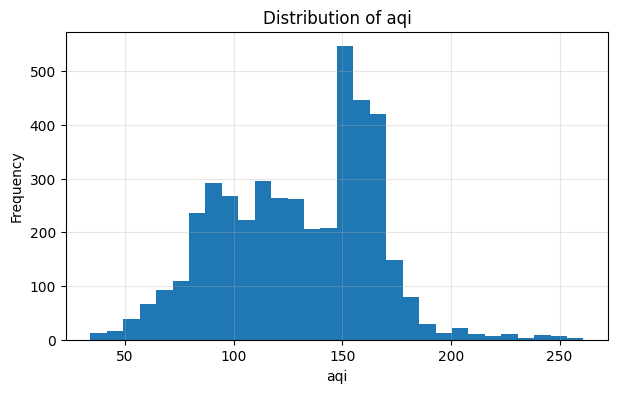

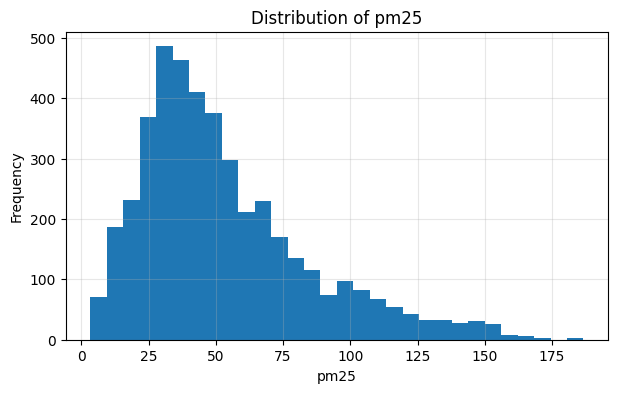

In [42]:
# ==============================
# 3. Distributions: Histograms per feature
# ==============================
numeric_cols = [
    "temperature", "humidity", "wind_speed", "pressure",
    "precipitation", "cloud_cover", "aqi", "pm25"
]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

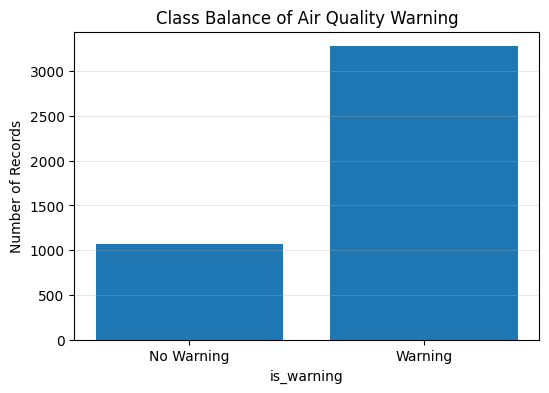

is_warning
0    1068
1    3276
Name: count, dtype: int64


In [43]:
# ==============================
# 4. Distributions: Class balance bar chart
# Label = is_warning
# ==============================
class_counts = df["is_warning"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Balance of Air Quality Warning")
plt.xlabel("is_warning")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["No Warning", "Warning"])
plt.grid(axis="y", alpha=0.3)
plt.show()

print(class_counts)

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


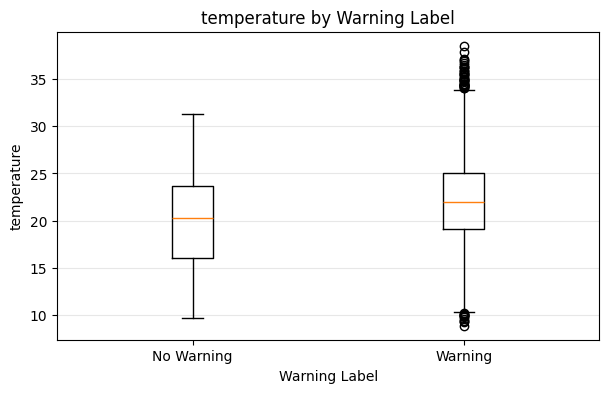

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


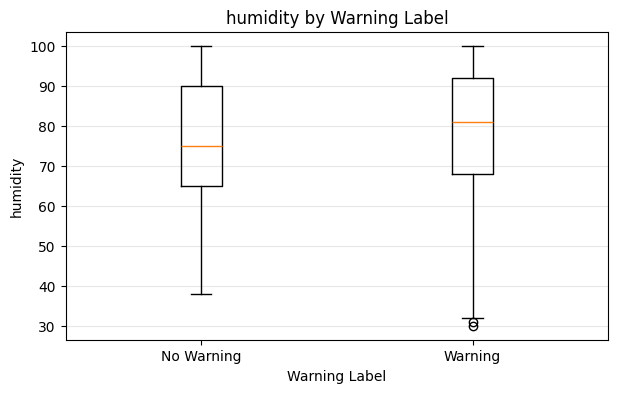

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


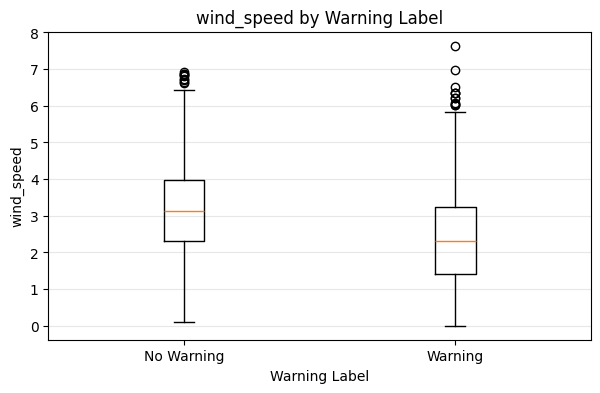

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


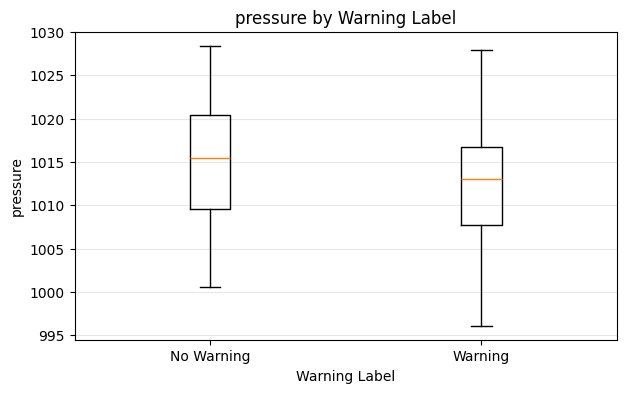

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


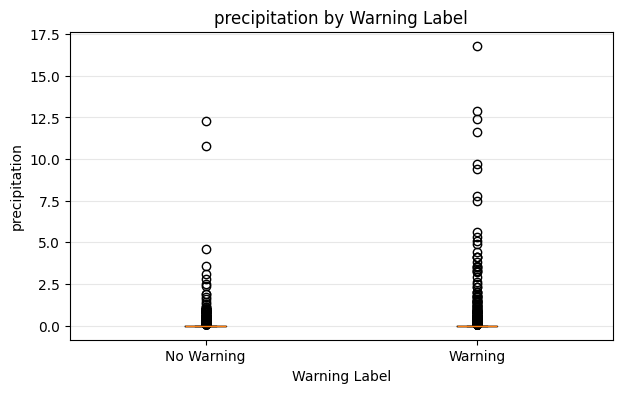

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


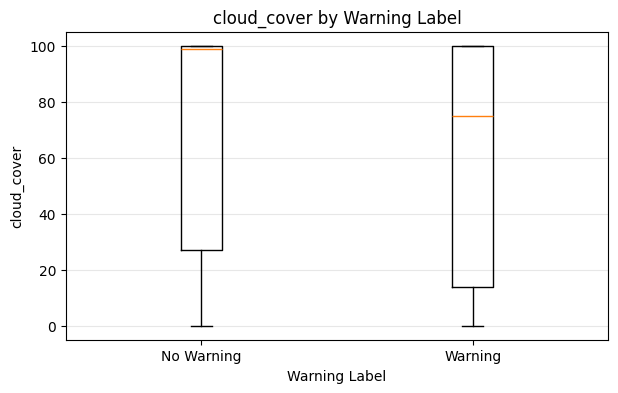

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


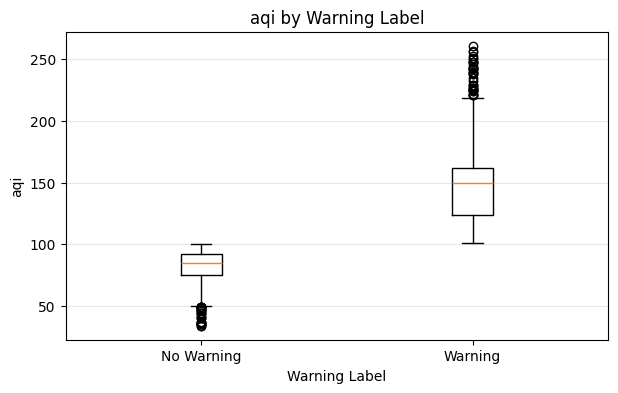

/tmp/ipykernel_57/2612456497.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


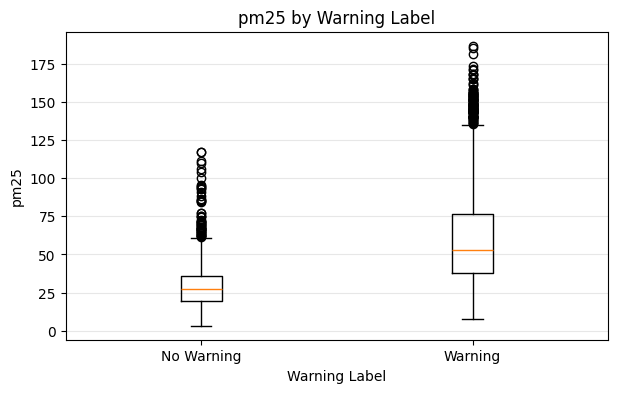

In [44]:
# ==============================
# 5. Distributions: Box plots by label
# ==============================
for col in numeric_cols:
    data_no_warning = df[df["is_warning"] == 0][col]
    data_warning = df[df["is_warning"] == 1][col]

    plt.figure(figsize=(7, 4))
    plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])
    plt.title(f"{col} by Warning Label")
    plt.xlabel("Warning Label")
    plt.ylabel(col)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

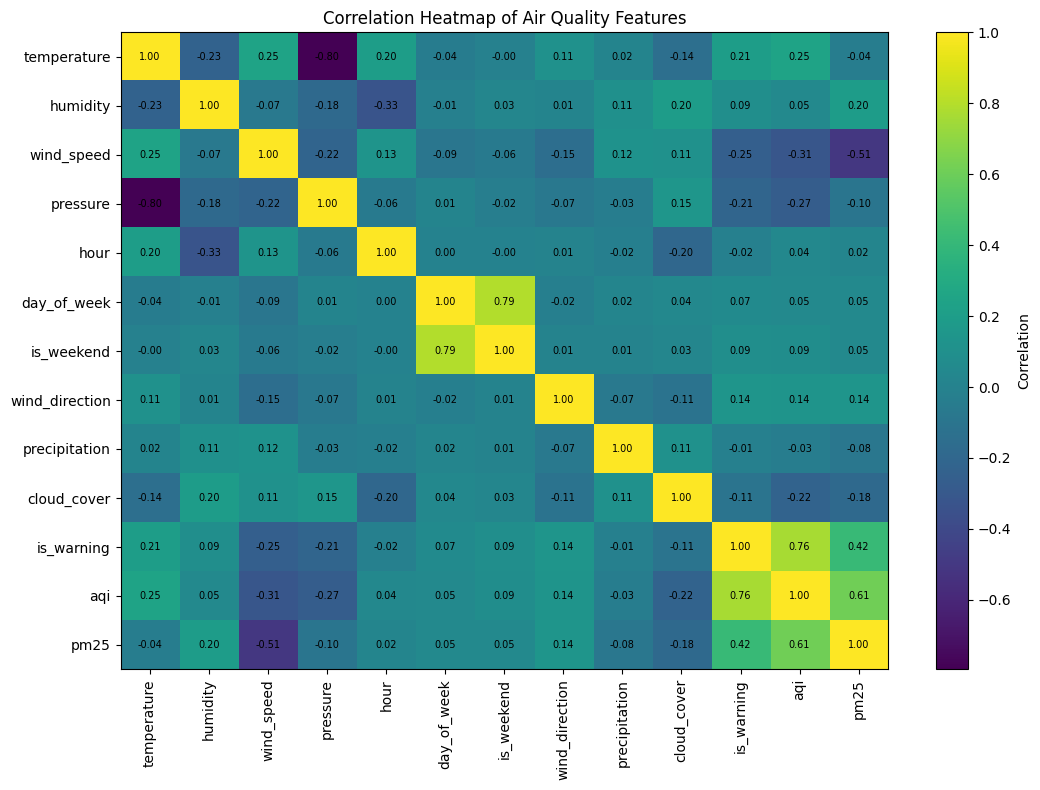

In [45]:
# ==============================
# 6. Relationships: Correlation heatmap
# ==============================
corr_cols = [
    "temperature", "humidity", "wind_speed", "pressure",
    "hour", "day_of_week", "is_weekend", "wind_direction",
    "precipitation", "cloud_cover", "is_warning", "aqi", "pm25"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Air Quality Features")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

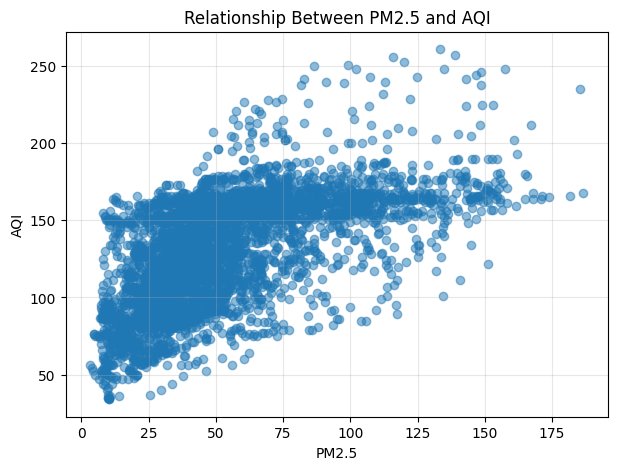

In [46]:
# ==============================
# 7. Relationships: PM2.5 vs AQI scatter plot
# ==============================
plt.figure(figsize=(7, 5))
plt.scatter(df["pm25"], df["aqi"], alpha=0.5)
plt.title("Relationship Between PM2.5 and AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_57/118109028.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])


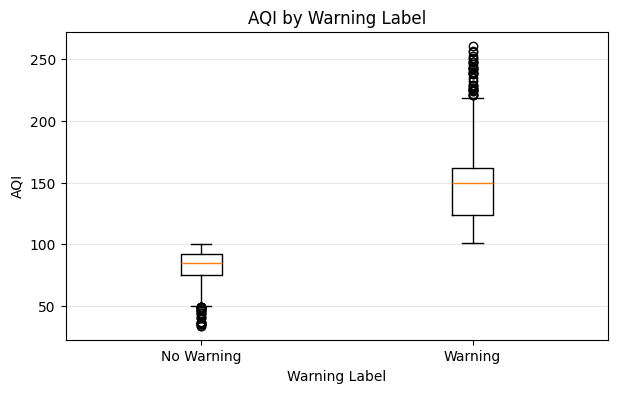

In [47]:
data_no_warning = df[df["is_warning"] == 0]["aqi"]
data_warning = df[df["is_warning"] == 1]["aqi"]

plt.figure(figsize=(7, 4))
plt.boxplot([data_no_warning, data_warning], labels=["No Warning", "Warning"])
plt.title("AQI by Warning Label")
plt.xlabel("Warning Label")
plt.ylabel("AQI")
plt.grid(axis="y", alpha=0.3)
plt.show()

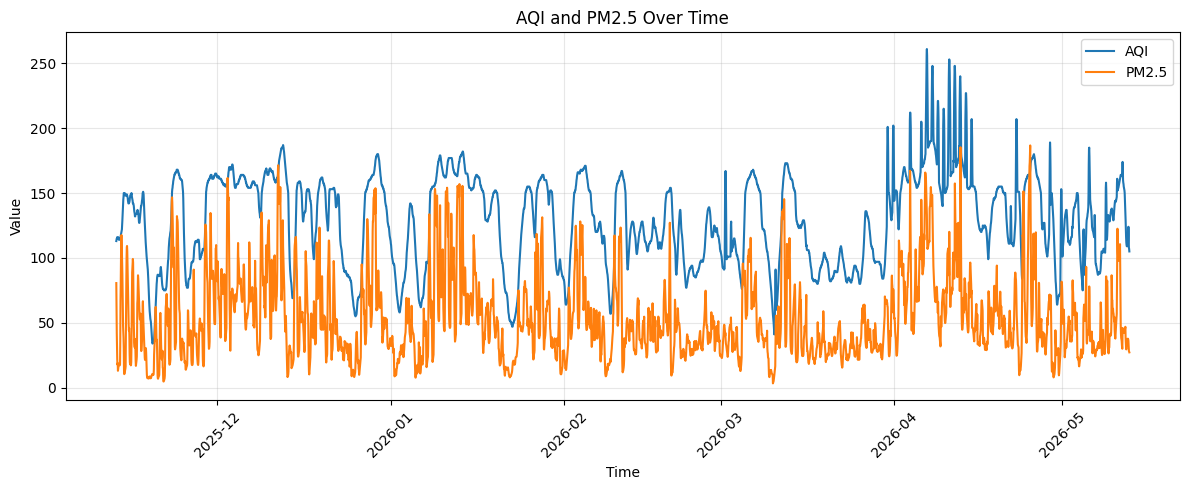

In [48]:
# ==============================
# 8. Relationships: Time-series line plot
# ==============================
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["aqi"], label="AQI")
plt.plot(df["timestamp"], df["pm25"], label="PM2.5")

plt.title("AQI and PM2.5 Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

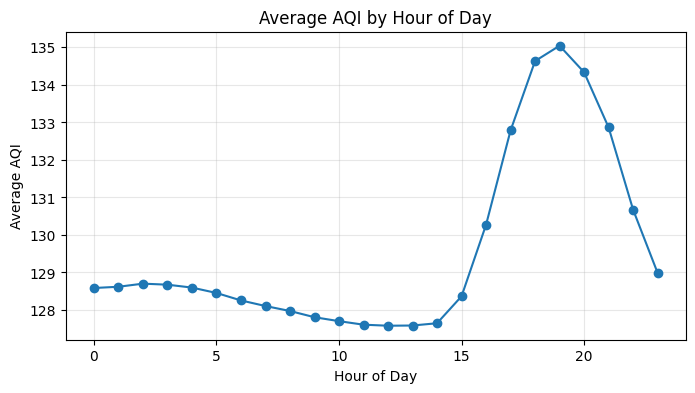

In [49]:
hourly_aqi = df.groupby("hour")["aqi"].mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o")
plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.grid(alpha=0.3)
plt.show()

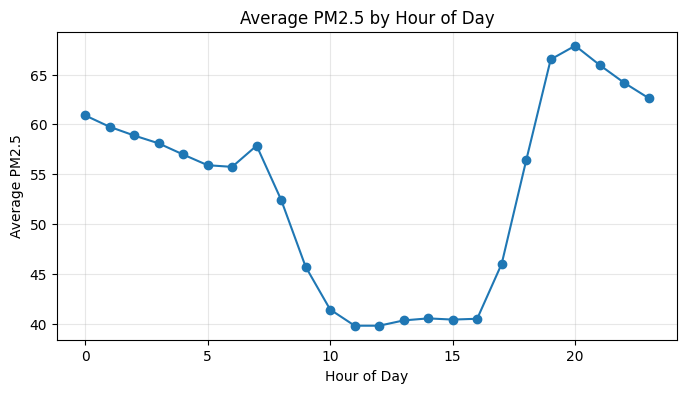

In [50]:
hourly_pm25 = df.groupby("hour")["pm25"].mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_pm25.index, hourly_pm25.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.grid(alpha=0.3)
plt.show()

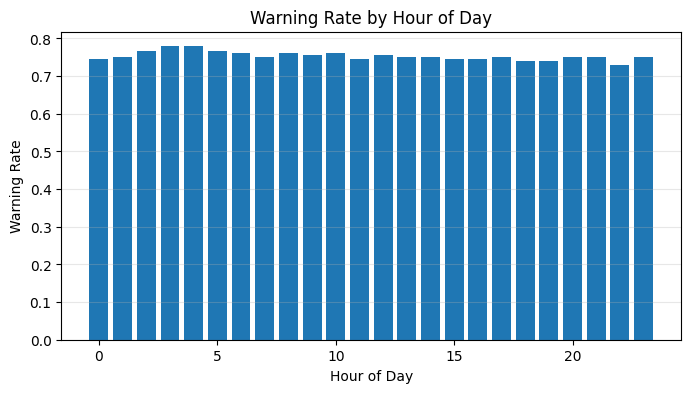

In [51]:
warning_by_hour = df.groupby("hour")["is_warning"].mean()

plt.figure(figsize=(8, 4))
plt.bar(warning_by_hour.index, warning_by_hour.values)
plt.title("Warning Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Warning Rate")
plt.grid(axis="y", alpha=0.3)
plt.show()

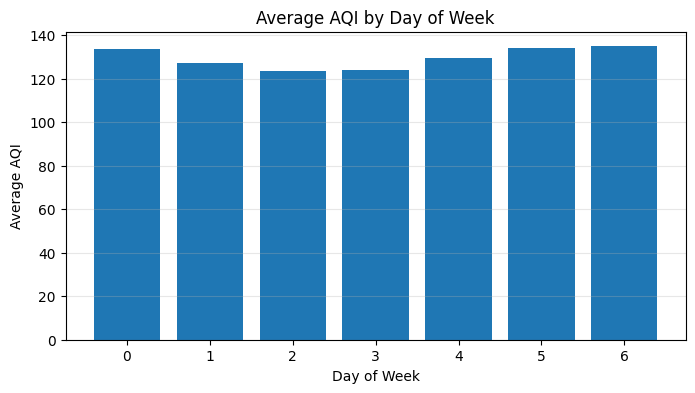

In [52]:
daily_aqi = df.groupby("day_of_week")["aqi"].mean()

plt.figure(figsize=(8, 4))
plt.bar(daily_aqi.index, daily_aqi.values)
plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.grid(axis="y", alpha=0.3)
plt.show()

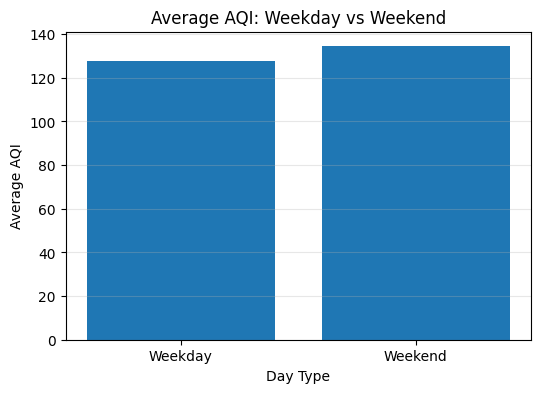

In [53]:
weekend_aqi = df.groupby("is_weekend")["aqi"].mean()

plt.figure(figsize=(6, 4))
plt.bar(["Weekday", "Weekend"], weekend_aqi.values)
plt.title("Average AQI: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average AQI")
plt.grid(axis="y", alpha=0.3)
plt.show()

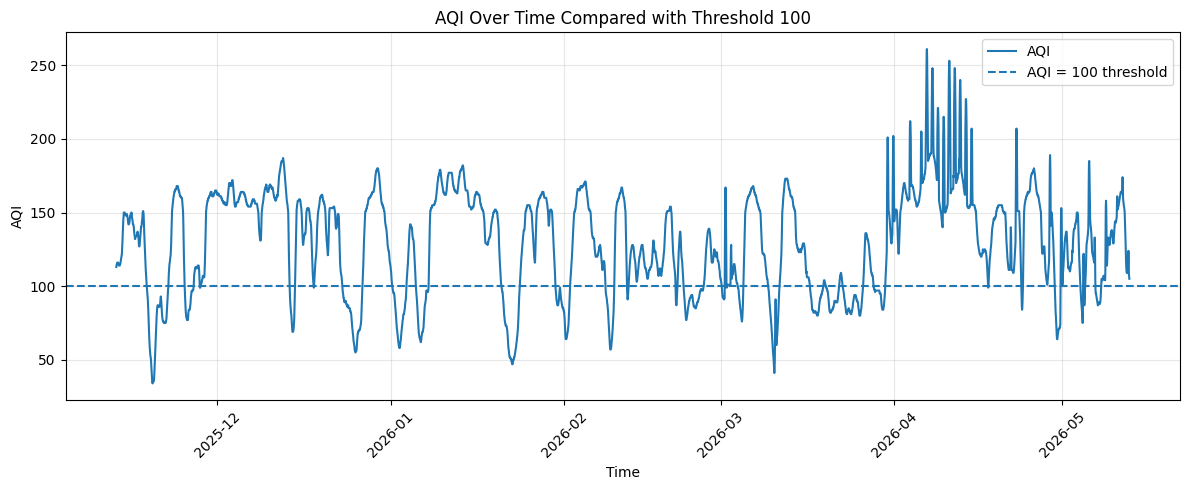

In [54]:
plt.figure(figsize=(12, 5))

plt.plot(df["timestamp"], df["aqi"], label="AQI")
plt.axhline(y=100, linestyle="--", label="AQI = 100 threshold")

plt.title("AQI Over Time Compared with Threshold 100")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

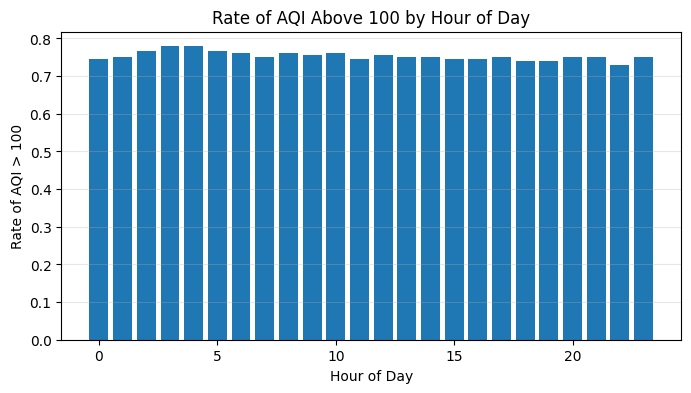

In [56]:
df["aqi_above_100"] = df["aqi"] > 100

hourly_above_100 = df.groupby("hour")["aqi_above_100"].mean()

plt.figure(figsize=(8, 4))
plt.bar(hourly_above_100.index, hourly_above_100.values)

plt.title("Rate of AQI Above 100 by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Rate of AQI > 100")
plt.grid(axis="y", alpha=0.3)
plt.show()

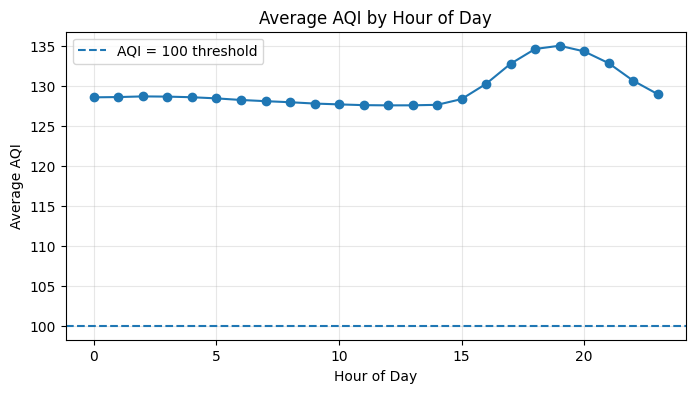

In [57]:
hourly_aqi = df.groupby("hour")["aqi"].mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o")
plt.axhline(y=100, linestyle="--", label="AQI = 100 threshold")

plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.show()